<a href="https://colab.research.google.com/github/HrithikVaya007/AI-ML-Projects-/blob/main/kmeansclustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
ds = pd.read_csv('Mall_Customers.csv')
x = ds.iloc[:,[3,4]].values


In [3]:
print(x)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

## Using the elbow method to find the optimal number of clusters

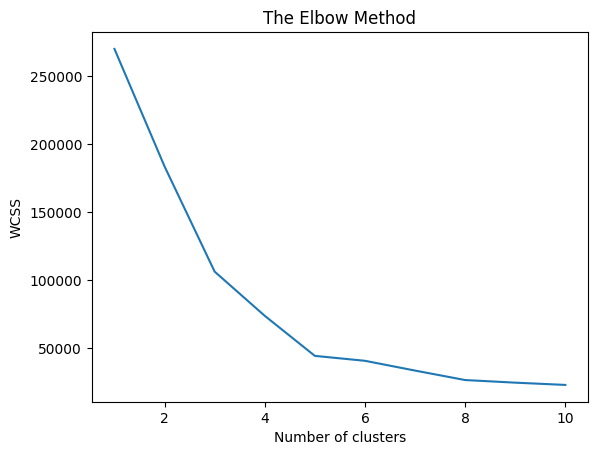

In [4]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


## Training the K-Means model on the dataset

In [5]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(x)

In [6]:
print(y_kmeans)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


## Visualising the clusters

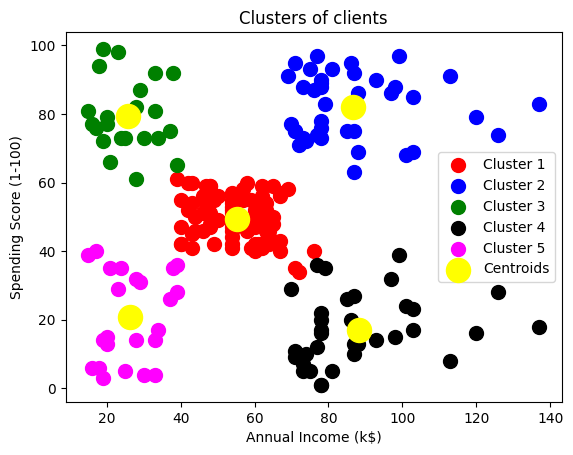

In [8]:
plt.scatter(x[y_kmeans == 0,0] , x[y_kmeans == 0 ,1] , s = 100, c = 'red',label = 'Cluster 1')
plt.scatter(x[y_kmeans == 1,0] , x[y_kmeans == 1 ,1] , s = 100, c = 'blue',label = 'Cluster 2')
plt.scatter(x[y_kmeans == 2,0] , x[y_kmeans == 2 ,1] , s = 100, c = 'green',label = 'Cluster 3')
plt.scatter(x[y_kmeans == 3,0] , x[y_kmeans == 3 ,1] , s = 100, c = 'black',label = 'Cluster 4')
plt.scatter(x[y_kmeans == 4,0] , x[y_kmeans == 4 ,1] , s = 100, c = 'magenta',label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:,0] , kmeans.cluster_centers_[: , 1] , s = 300 , c = 'yellow' , label = 'Centroids')
plt.title('Clusters of clients')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

### How K-Means Assigns Data Points to Clusters

The K-Means algorithm uses an iterative process to group data points into clusters. It primarily relies on the **distance** between data points and the center of the clusters (called **centroids**).

Here are the key steps involved in deciding which data point goes to which cluster:

1.  **Initialization**: First, 'K' initial centroids are chosen. These are essentially the starting 'centers' for your clusters. This can be done randomly or through more sophisticated methods (like `k-means++` which you used, designed to spread out the initial centroids).

2.  **Assignment Step (E-step - Expectation)**: For every single data point in your dataset, the algorithm calculates its distance to *each* of the 'K' centroids. The distance is typically Euclidean distance (the straight-line distance between two points).

    *   **The crucial decision**: Each data point is then assigned to the cluster whose centroid is **closest** to it. This means a point will join the cluster of the centroid it is 'nearest' to.

3.  **Update Step (M-step - Maximization)**: Once all data points have been assigned to a cluster, the algorithm recalculates the position of each cluster's centroid. The new centroid for each cluster is simply the **mean (average) of all the data points currently assigned to that cluster**.

4.  **Iteration**: Steps 2 and 3 are repeated. Data points are reassigned to the *new* closest centroids, and then the centroids are recalculated again. This process continues until one of the following conditions is met:
    *   The centroids no longer move significantly (or at all) between iterations.
    *   The cluster assignments of the data points no longer change.
    *   A maximum number of iterations is reached.


In essence, the algorithm constantly tries to minimize the **Within-Cluster Sum of Squares (WCSS)**, which is the sum of the squared distances between each data point and its assigned cluster centroid. By finding the closest centroid for each point and then moving the centroids to the center of their assigned points, it converges to a state where the points are as close as possible to their own cluster's center.